<div style="text-align: center;">
    <img src="https://user-images.githubusercontent.com/86345471/221379942-51f24819-1f76-4289-8dee-06ea69f730f6.png" alt=Main "KPI />
</di>

<hr>

**Завдання:** Застосувати алгоритми дерева рішень та лісу дерев рішень до трьох датасетів https://www.kaggle.com/datasets?search=security, проаналізувати переваги та недоліки наведених алгоритмів, зробити висновки щодо якості класифікації різних даних в залежності від особливостей даних у датасетах.

**Теорія:** Дерево рiшень — це метод подання вирiшальних правил в iєрархiчнiй структурi, що складається з елементiв двох типiв – вузлiв (node) та листя (leaf). У вузлах мiстяться вирiшальнi правила i проводиться перевiрка вiдповiдностi прикладiв цього правила за яким-небудь атрибутом навчальної множини. На вiдмiну вiд вузла в листi мiститься не правило, а пiдмножина об’єктiв, що задовольняють усi правила гiлки, яка закiнчується цим листом. Випадковий лiс має таку назву, бо щоразу обрається випадковий набiр даних i критерiїв і будується з багатьох дерев. Простим голосуванням обирається варiант, який одержить найбiльше голосiв.

<hr>

## Датасет логів мережевого фаєрвола

### 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

### 2. Завантаження даних

In [2]:
df_firewall = pd.read_csv('./Firewall.csv')
df_firewall.shape 

(65532, 12)

### 3. Огляд даних

In [3]:
df_firewall.sample(5)

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
42943,61181,445,0,0,drop,70,70,0,1,0,1,0
20905,49595,53,17154,53,allow,176,90,86,2,30,1,1
47818,40705,443,7502,443,allow,5721,3240,2481,35,147,14,21
7265,58638,5900,0,0,deny,62,62,0,1,0,1,0
52314,56619,80,59686,80,allow,234,234,0,4,12,4,0


In [4]:
df_firewall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Source Port           65532 non-null  int64 
 1   Destination Port      65532 non-null  int64 
 2   NAT Source Port       65532 non-null  int64 
 3   NAT Destination Port  65532 non-null  int64 
 4   Action                65532 non-null  object
 5   Bytes                 65532 non-null  int64 
 6   Bytes Sent            65532 non-null  int64 
 7   Bytes Received        65532 non-null  int64 
 8   Packets               65532 non-null  int64 
 9   Elapsed Time (sec)    65532 non-null  int64 
 10  pkts_sent             65532 non-null  int64 
 11  pkts_received         65532 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 6.0+ MB


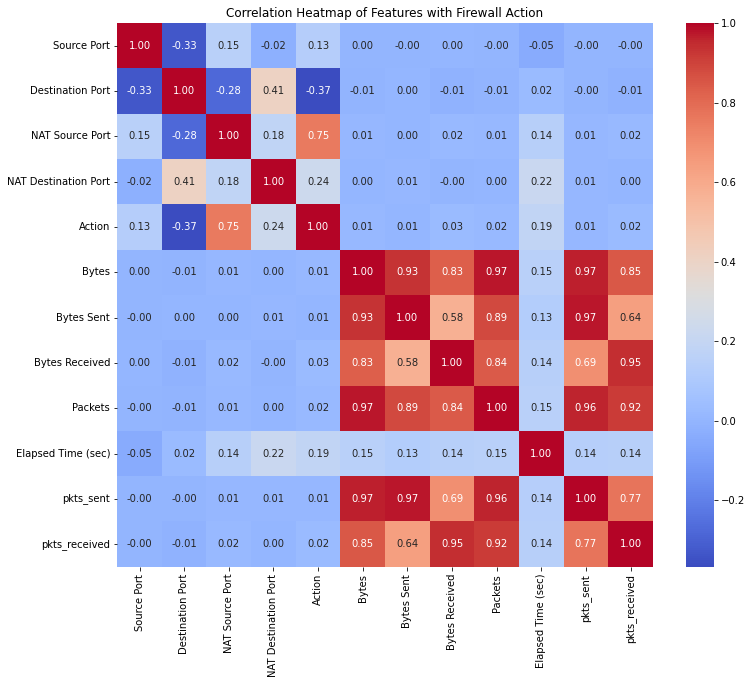

In [5]:
dataset = df_firewall.copy()
dataset['Action'] = dataset['Action'].apply(lambda x: 1 if x == 'allow' else 0)

plt.figure(figsize=(12, 10))
correlation_matrix = dataset.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Features with Firewall Action')
plt.show()

### 4. Попередня обробка даних

In [6]:
df_firewall.dropna()
df_firewall.shape

(65532, 12)

### 5. Розділення на навчальні та тестові дані¶

In [7]:
X = df_firewall.drop(['Source Port', 'Destination Port', 'NAT Source Port', 'NAT Destination Port', 'Action', 'Elapsed Time (sec)'], axis=1)
y= df_firewall['Action']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

### 6. Стандартизація даних

In [8]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train) 
scaled_X_test = scaler.transform(X_test)

### 7.1. Навчання моделі дерева рішень

In [9]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(scaled_X_train, y_train)

DecisionTreeClassifier(max_depth=3)

### 8.1. Прогнозування

In [10]:
y_pred = model.predict(scaled_X_test)

### 9.1. Оцінка моделі

In [11]:
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

       allow       1.00      0.95      0.97      7567
        deny       0.93      0.67      0.78      2974
        drop       0.68      1.00      0.81      2560
  reset-both       0.25      0.17      0.20         6

    accuracy                           0.90     13107
   macro avg       0.72      0.70      0.69     13107
weighted avg       0.92      0.90      0.90     13107

Confusion Matrix:
 [[7182  135  247    3]
 [   5 1993  976    0]
 [   0    0 2560    0]
 [   0    5    0    1]]


### 10.1. Візуалізація результатів

#### Побудова матриці плутанини

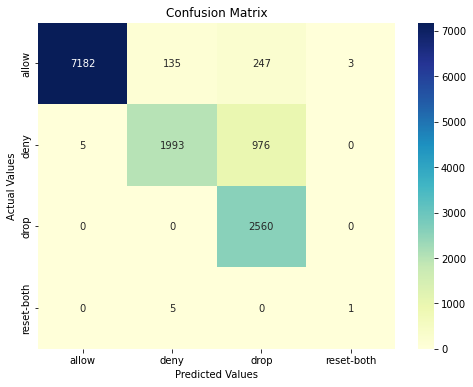

In [12]:
class_names=['allow', 'deny', 'drop', 'reset-both'] 
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

#### Побудова дерева рішень

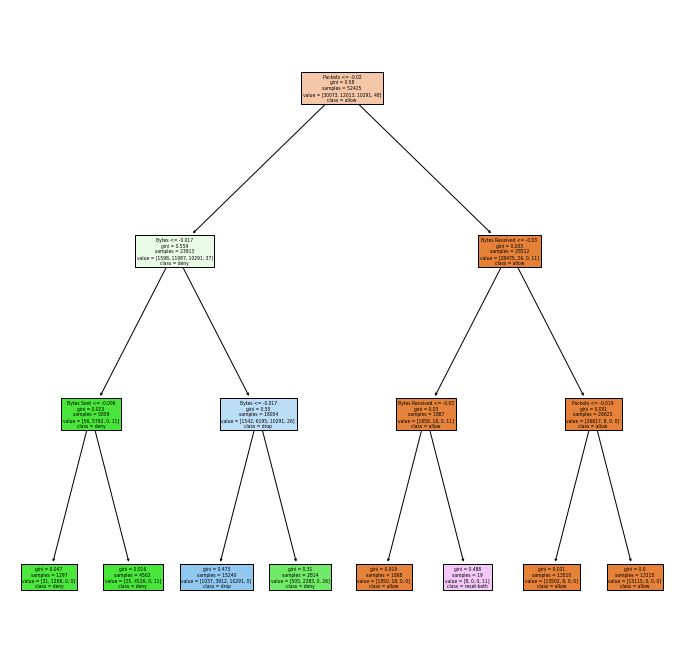

In [13]:
plt.figure(figsize = (12, 12))
plot_tree(model, feature_names = ['Bytes', 'Bytes Sent', 'Bytes Received', 'Packets', 'pkts_sent', 'pkts_received'], class_names=['allow', 'deny', 'drop', 'reset-both'], filled = True)
plt.savefig('tree_firewall.png')
plt.show()

### 7.2. Навчання моделі лісу дерев рішень

In [14]:
clf = RandomForestClassifier(n_estimators=100, max_depth=5) 
clf.fit(scaled_X_train, y_train)

RandomForestClassifier(max_depth=5)

### 8.2. Прогнозування

In [15]:
predictions = clf.predict(scaled_X_test)

### 9.2. Оцінка моделі

In [16]:
report = classification_report(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

       allow       1.00      0.95      0.97      7567
        deny       0.74      0.99      0.85      2974
        drop       0.88      0.66      0.76      2560
  reset-both       1.00      0.17      0.29         6

    accuracy                           0.90     13107
   macro avg       0.91      0.69      0.72     13107
weighted avg       0.92      0.90      0.90     13107

Confusion Matrix:
 [[7185  170  212    0]
 [   5 2955   14    0]
 [   0  862 1698    0]
 [   0    5    0    1]]


### 10.2. Візуалізація результатів

#### Побудова матриці плутанини

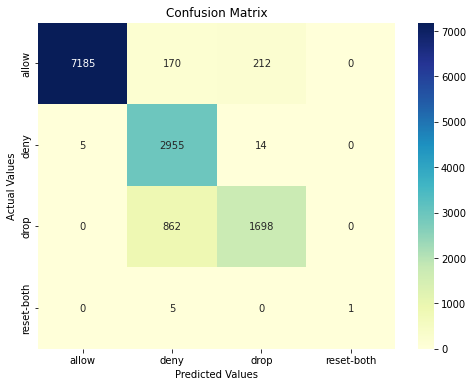

In [17]:
class_names=['allow', 'deny', 'drop', 'reset-both'] 
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

#### Побудова оптимального дерева рішень

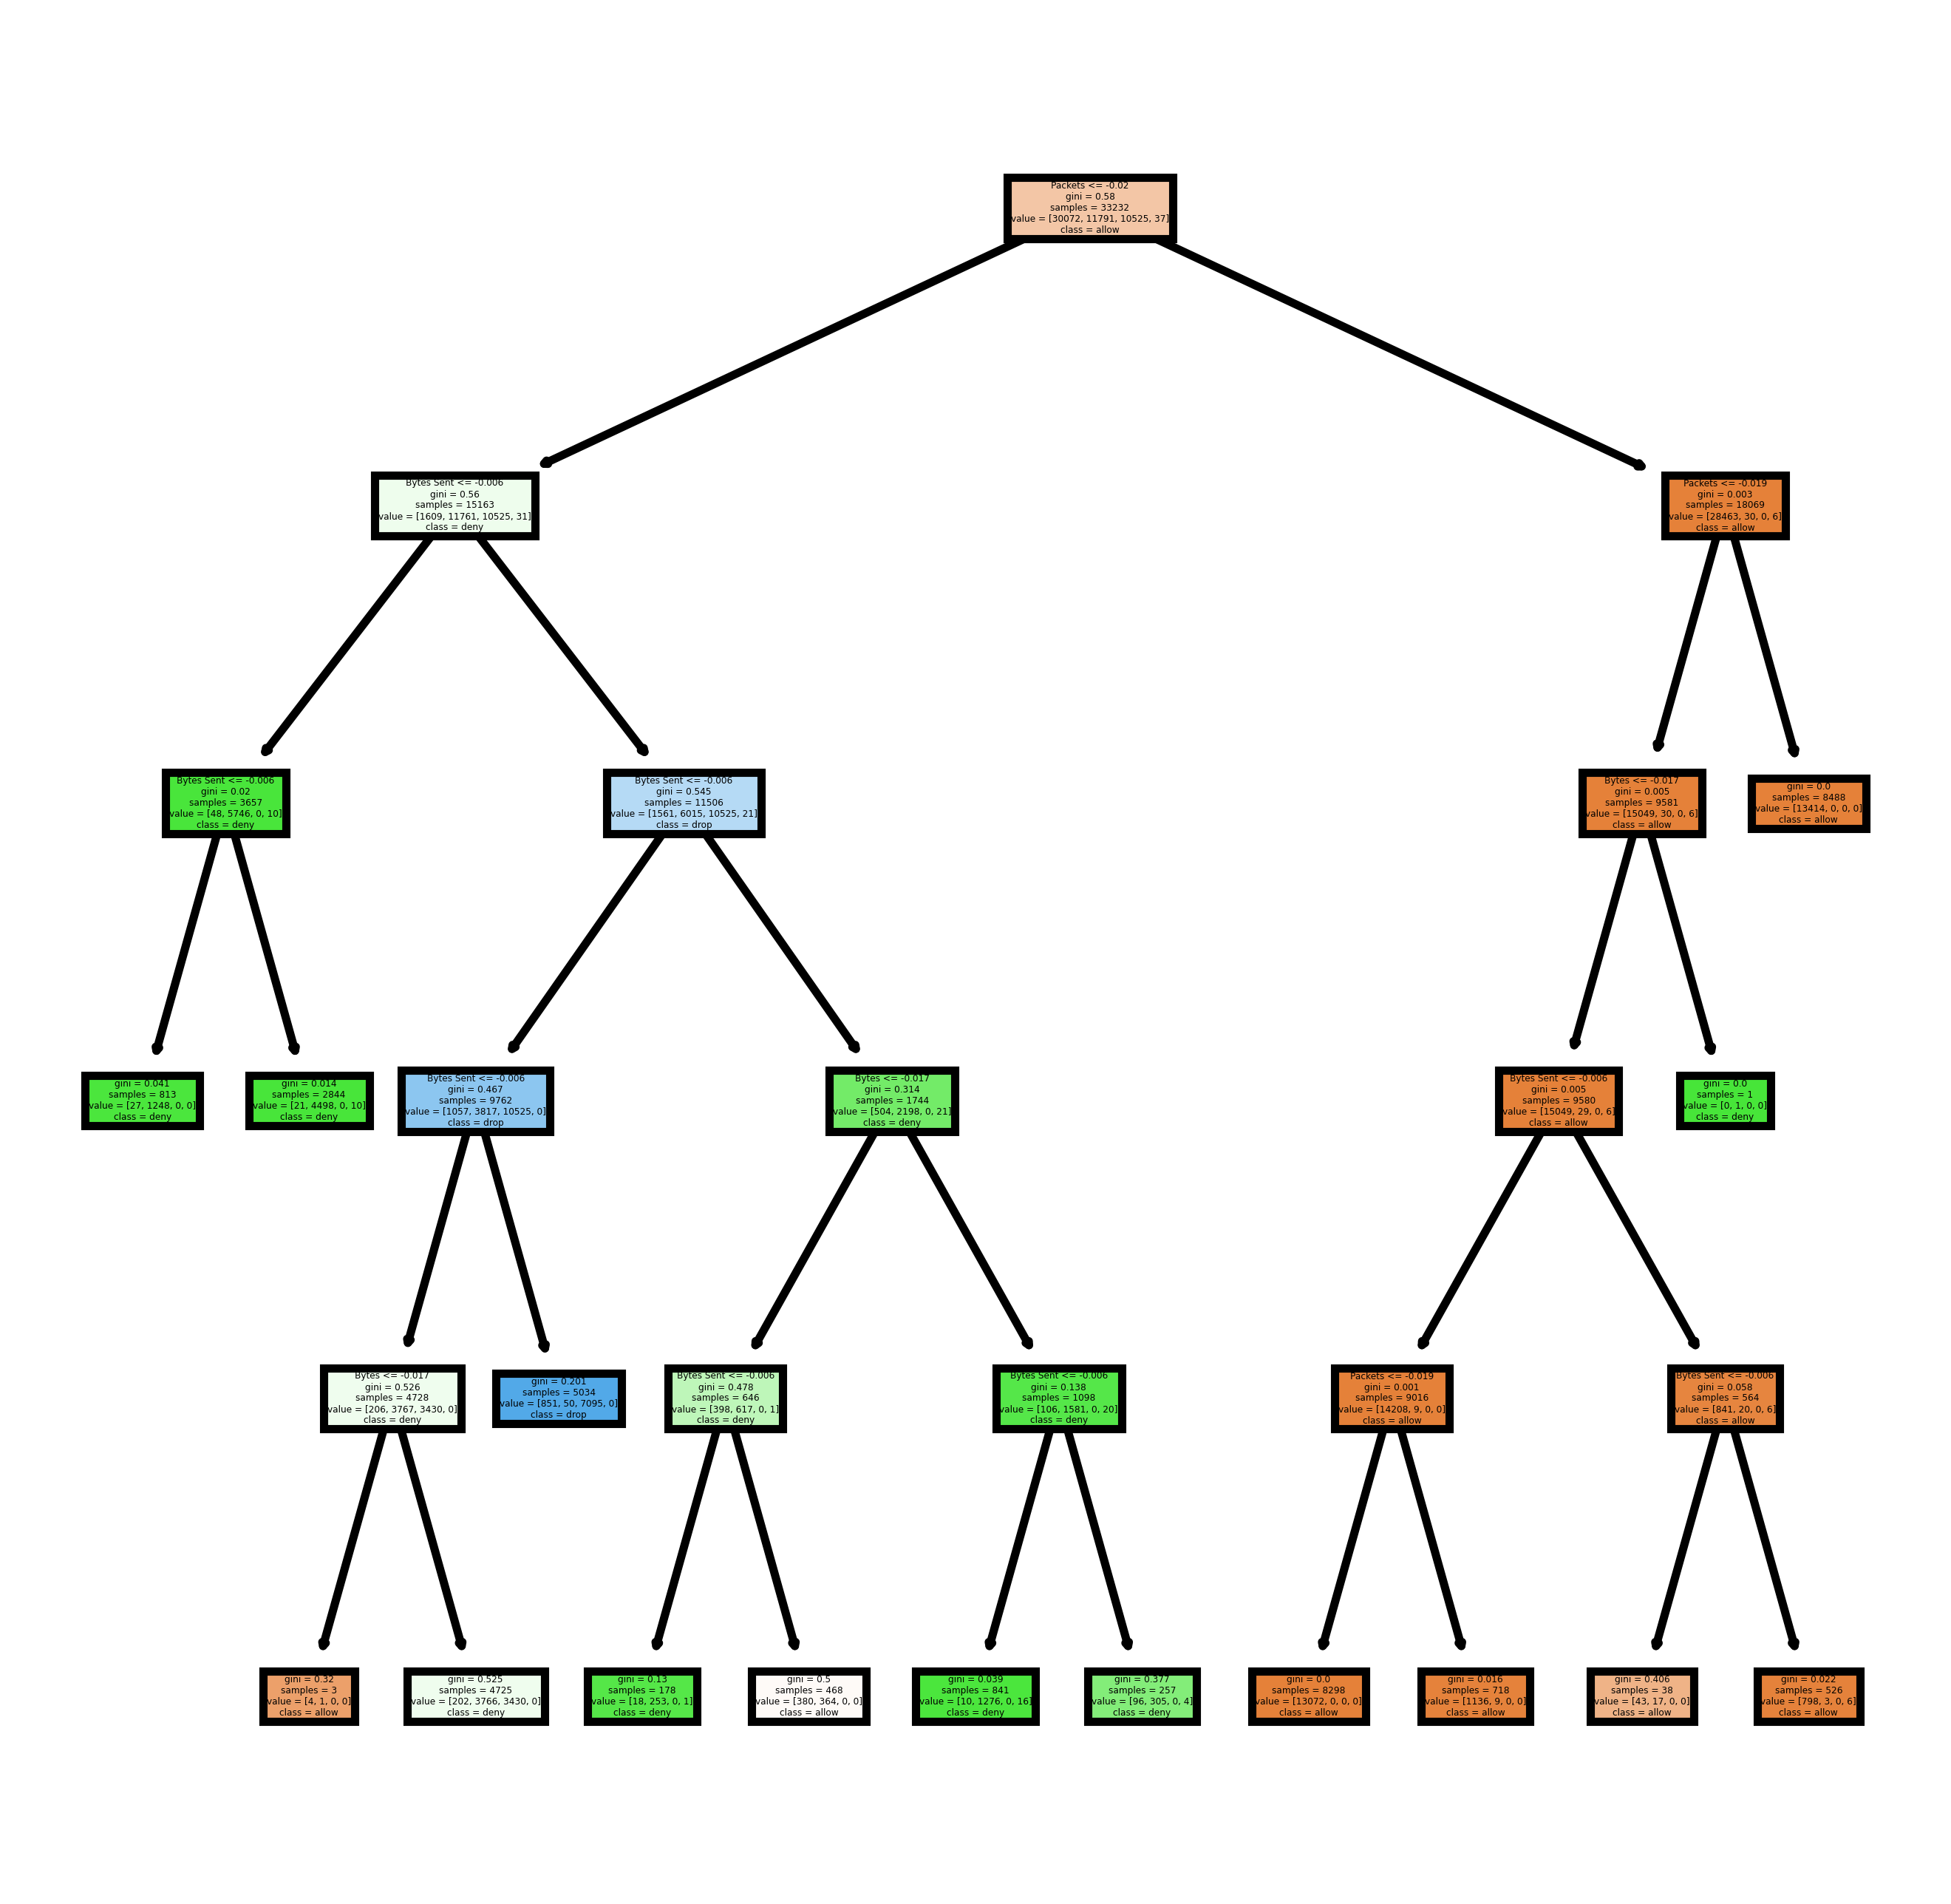

In [18]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 4), dpi=800)
plot_tree(clf.estimators_[0], feature_names = ['Bytes', 'Bytes Sent', 'Bytes Received', 'Packets', 'pkts_sent', 'pkts_received'], class_names=['allow', 'deny', 'drop', 'reset-both'], filled = True)
fig.savefig('forest_firewall.png')

<hr>

<hr>

## Датасет легітимних файлів

### 2. Завантаження даних

In [19]:
df_filename = pd.read_csv('./data_file.csv')  # https://www.kaggle.com/datasets/amdj3dax/ransomware-detection-data-set
df_filename.shape 

(62485, 18)

### 3. Огляд даних

In [20]:
df_filename.sample(5)

,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
2138,audiodg (6).exe,a4c5c64261813d233d38b3e09d983f37,34404,28,5600,6,6,0,0,4096,9,0,8,524288,33088,2096,0,1
53851,VirusShare_3fb693cae4a407243e5193fd903a884a,3fb693cae4a407243e5193fd903a884a,332,56,119280,0,5,0,0,118784,11,0,5,1048576,33088,620472,0,0
47675,VirusShare_e47ffba764e93399de9b79282e99e67c,e47ffba764e93399de9b79282e99e67c,332,28,4336,0,4,30752,4181,610768,8,0,5,1048576,0,14256,0,0
58582,VirusShare_98cc444b73318f1d839ae65816102610,98cc444b73318f1d839ae65816102610,332,0,0,5,5,0,0,425984,11,0,4,1048576,64,0,0,0
440,JavaAccessBridge-64.dll,bb8b343f78e9b4d5bc38dc9c9b62fe05,34404,28,70176,0,5,133120,2104,69632,10,0,6,1048576,320,1888,0,1


In [21]:
df_filename.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62485 entries, 0 to 62484
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   FileName            62485 non-null  object
 1   md5Hash             62485 non-null  object
 2   Machine             62485 non-null  int64 
 3   DebugSize           62485 non-null  int64 
 4   DebugRVA            62485 non-null  int64 
 5   MajorImageVersion   62485 non-null  int64 
 6   MajorOSVersion      62485 non-null  int64 
 7   ExportRVA           62485 non-null  int64 
 8   ExportSize          62485 non-null  int64 
 9   IatVRA              62485 non-null  int64 
 10  MajorLinkerVersion  62485 non-null  int64 
 11  MinorLinkerVersion  62485 non-null  int64 
 12  NumberOfSections    62485 non-null  int64 
 13  SizeOfStackReserve  62485 non-null  int64 
 14  DllCharacteristics  62485 non-null  int64 
 15  ResourceSize        62485 non-null  int64 
 16  BitcoinAddresses    62

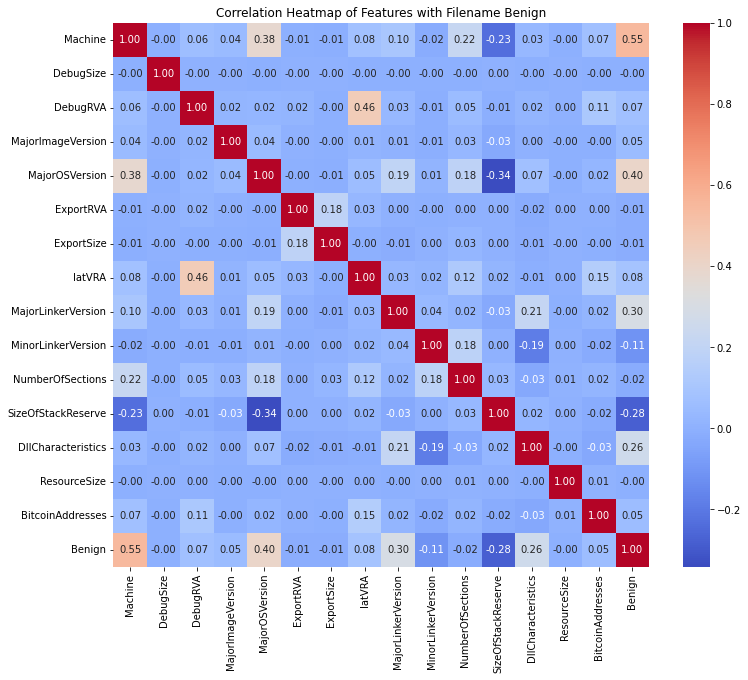

In [22]:
dataset = df_filename.copy()
dataset.drop(['FileName', 'md5Hash'], axis=1)

plt.figure(figsize=(12, 10))
correlation_matrix = dataset.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Features with Filename Benign')
plt.show()

### 4. Попередня обробка даних

In [23]:
df_filename.dropna()
df_filename.shape

(62485, 18)

### 5. Розділення на навчальні та тестові дані

In [24]:
X = df_filename.drop(['FileName', 'md5Hash', 'Benign'], axis=1)
y= df_filename['Benign']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

### 6. Стандартизація даних

In [25]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train) 
scaled_X_test = scaler.transform(X_test)

### 7.1. Навчання моделі дерева рішень

In [26]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(scaled_X_train, y_train)

DecisionTreeClassifier(max_depth=3)

### 8.1. Прогнозування

In [27]:
y_pred = model.predict(scaled_X_test)

### 9.1. Оцінка моделі

In [28]:
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96      7005
           1       0.92      0.97      0.95      5492

    accuracy                           0.95     12497
   macro avg       0.95      0.95      0.95     12497
weighted avg       0.95      0.95      0.95     12497

Confusion Matrix:
 [[6557  448]
 [ 159 5333]]


### 10.1. Візуалізація результатів

#### Побудова матриці плутанини

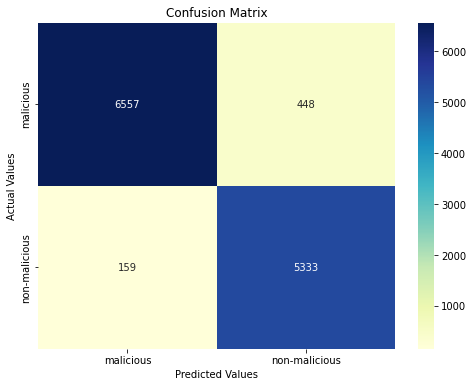

In [29]:
class_names=['malicious', 'non-malicious'] 
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

#### Побудова дерева рішень

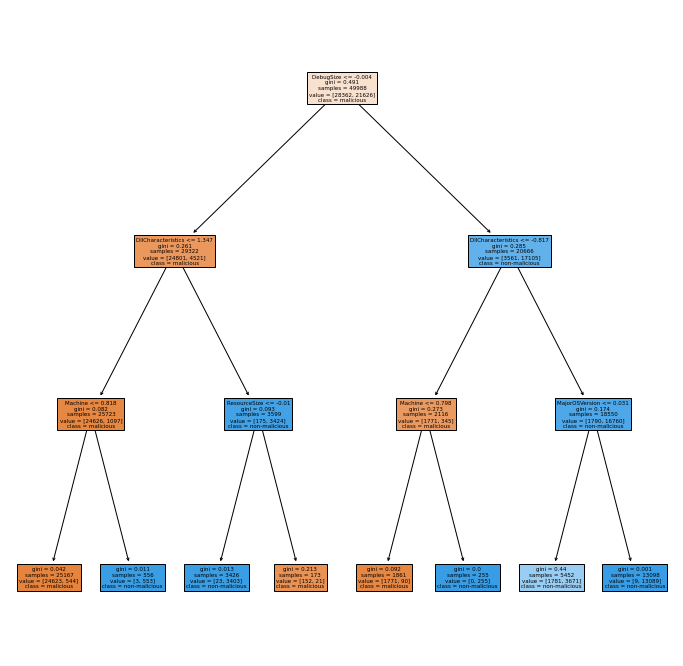

In [30]:
plt.figure(figsize = (12, 12))
plot_tree(model, feature_names = X.columns, class_names=['malicious', 'non-malicious'], filled = True)
plt.savefig('tree_filename.png')
plt.show()

### 7.2. Навчання моделі дерева рішень

In [31]:
clf = RandomForestClassifier(n_estimators=100, max_depth=5) 
clf.fit(scaled_X_train, y_train)

RandomForestClassifier(max_depth=5)

### 8.2. Прогнозування

In [32]:
predictions = clf.predict(scaled_X_test)

### 9.2. Оцінка моделі

In [33]:
report = classification_report(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      7005
           1       0.99      0.97      0.98      5492

    accuracy                           0.98     12497
   macro avg       0.98      0.98      0.98     12497
weighted avg       0.98      0.98      0.98     12497

Confusion Matrix:
 [[6932   73]
 [ 148 5344]]


### 10.2. Візуалізація результатів

#### Побудова матриці плутанини

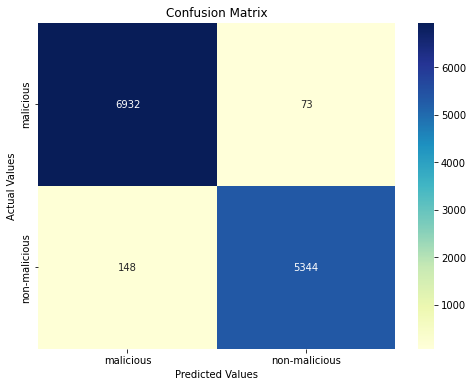

In [34]:
class_names=['malicious', 'non-malicious'] 
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

#### Побудова оптимального дерева рішень

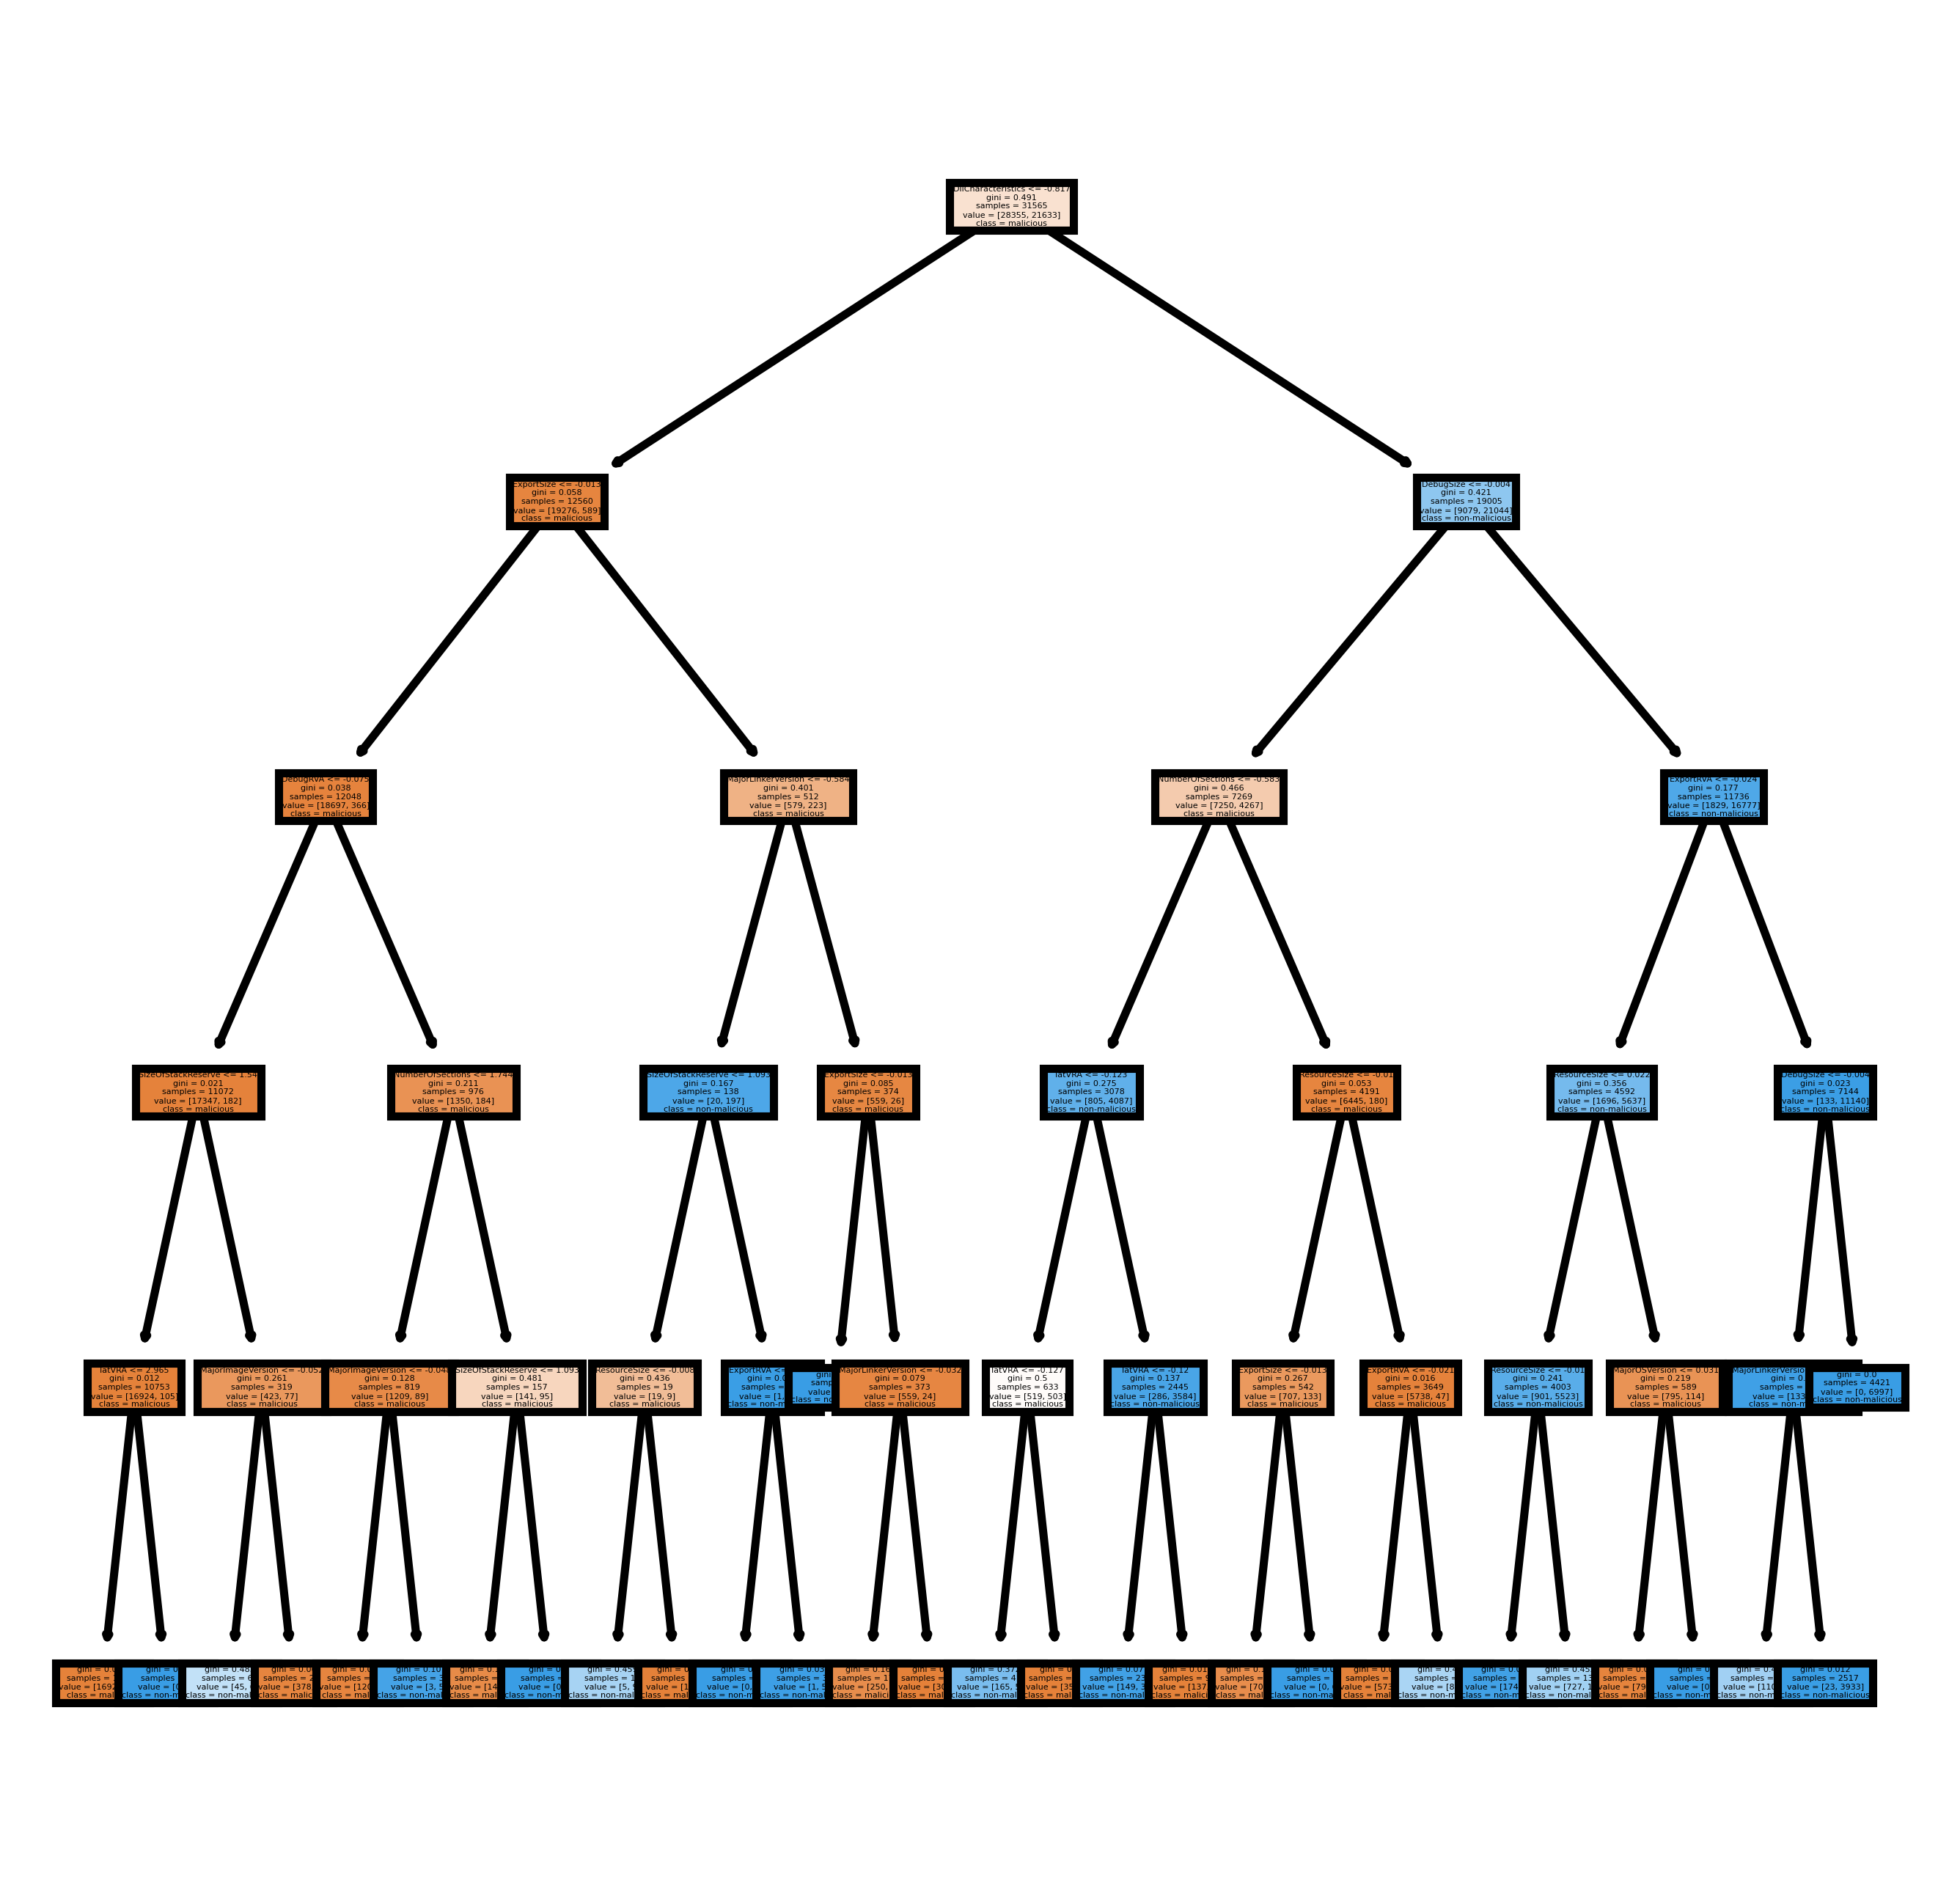

In [35]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
plot_tree(clf.estimators_[0], feature_names = X.columns, class_names=['malicious', 'non-malicious'], filled = True)
fig.savefig('forest_filename.png')

<hr>

<hr>

## Датасет підозри на спам-розсилку

### 2. Завантаження даних

In [36]:
df_spambase = pd.read_csv('./spambase_csv.csv')  # https://www.kaggle.com/datasets/somesh24/spambase 
df_spambase.shape

(4601, 58)

### 3. Огляд даних

In [37]:
df_spambase.sample(5)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
4500,0.78,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,...,0.0,0.000,0.0,0.000,0.0,0.0,1.875,8,30,0
1219,1.17,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,...,0.0,0.000,0.0,0.924,0.0,0.0,1.966,10,59,1
3600,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,...,0.0,0.000,0.0,0.000,0.0,0.0,1.000,1,4,0
397,0.00,0.0,0.67,0.0,0.0,0.0,0.67,2.02,0.0,0.0,...,0.0,0.095,0.0,0.286,0.0,0.0,5.558,39,189,1
3661,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,...,0.0,0.000,0.0,0.000,0.0,0.0,1.000,1,5,0


In [38]:
df_spambase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

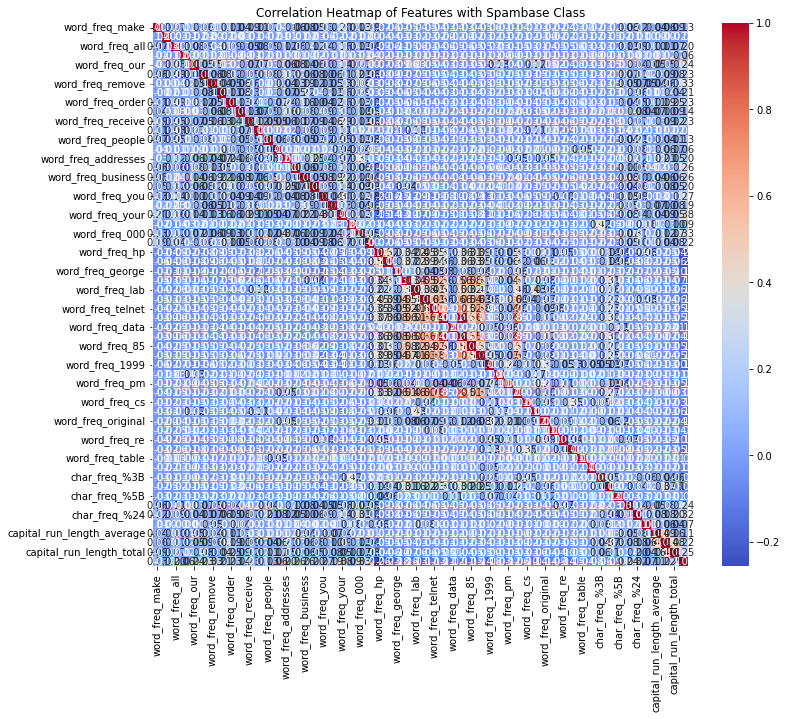

In [39]:
dataset = df_spambase.copy()

plt.figure(figsize=(12, 10))
correlation_matrix = dataset.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Features with Spambase Class')
plt.show()

### 4. Попередня обробка даних

In [40]:
df_spambase.dropna()
df_spambase.shape

(4601, 58)

### 5. Розділення на навчальні та тестові дані

In [41]:
corr_matrix = df_spambase.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.2)]
X = df_spambase.drop(to_drop, axis=1)
y = df_spambase['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

### 6. Стандартизація даних

In [42]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

### 7.1. Навчання моделі дерева рішень

In [43]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(scaled_X_train, y_train)

DecisionTreeClassifier(max_depth=3)

### 8.1. Прогнозування

In [44]:
y_pred = model.predict(scaled_X_test)

### 9.1. Оцінка моделі

In [45]:
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       545
           1       0.90      0.78      0.84       376

    accuracy                           0.88       921
   macro avg       0.88      0.86      0.87       921
weighted avg       0.88      0.88      0.87       921

Confusion Matrix:
 [[513  32]
 [ 83 293]]


### 10.1. Візуалізація результатів

#### Побудова матриці плутанини

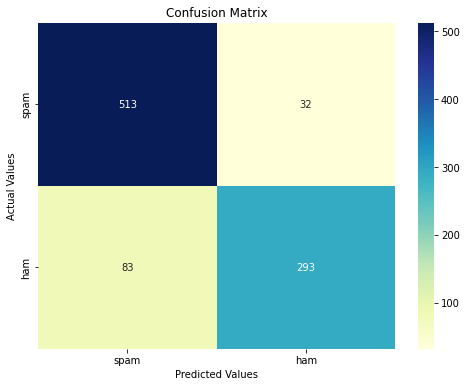

In [46]:
class_names=['spam', 'ham'] 
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

#### Побудова дерева рішень

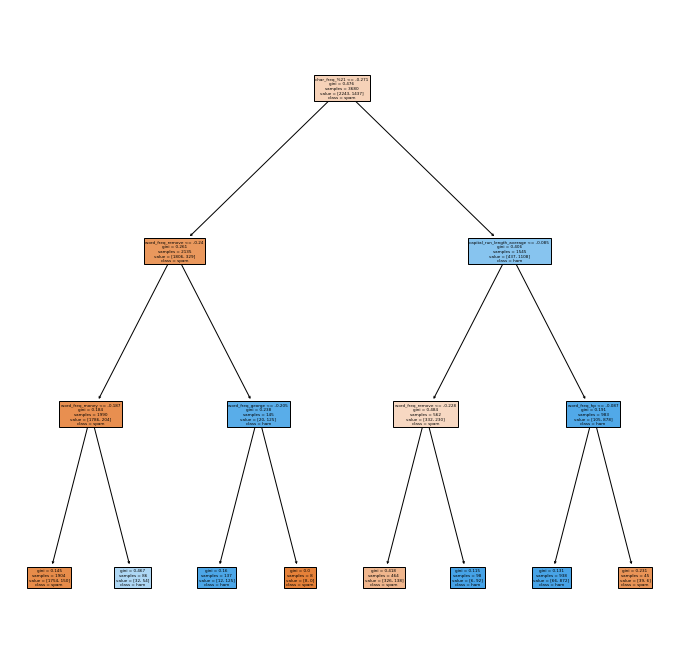

In [47]:
plt.figure(figsize = (12, 12))
plot_tree(model, feature_names = X.columns, class_names=['spam', 'ham'], filled = True)
plt.savefig('tree_spambase.png')
plt.show()

#### 7.2. Навчання моделі дерева рішень

In [48]:
clf = RandomForestClassifier(n_estimators=100, max_depth=5) 
clf.fit(scaled_X_train, y_train)

RandomForestClassifier(max_depth=5)

#### 8.2. Прогнозування

In [49]:
predictions = clf.predict(scaled_X_test)

#### 9.2. Оцінка моделі

In [50]:
report = classification_report(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       545
           1       0.96      0.81      0.87       376

    accuracy                           0.91       921
   macro avg       0.92      0.89      0.90       921
weighted avg       0.91      0.91      0.90       921

Confusion Matrix:
 [[531  14]
 [ 73 303]]


#### 10.2. Візуалізація результатів

#### Побудова матриці плутанини

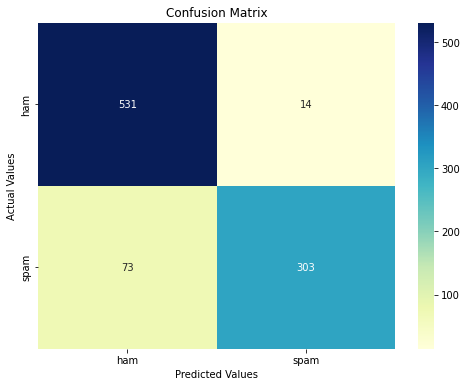

In [51]:
class_names=['ham', 'spam'] 
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

#### Побудова оптимального дерева рішень

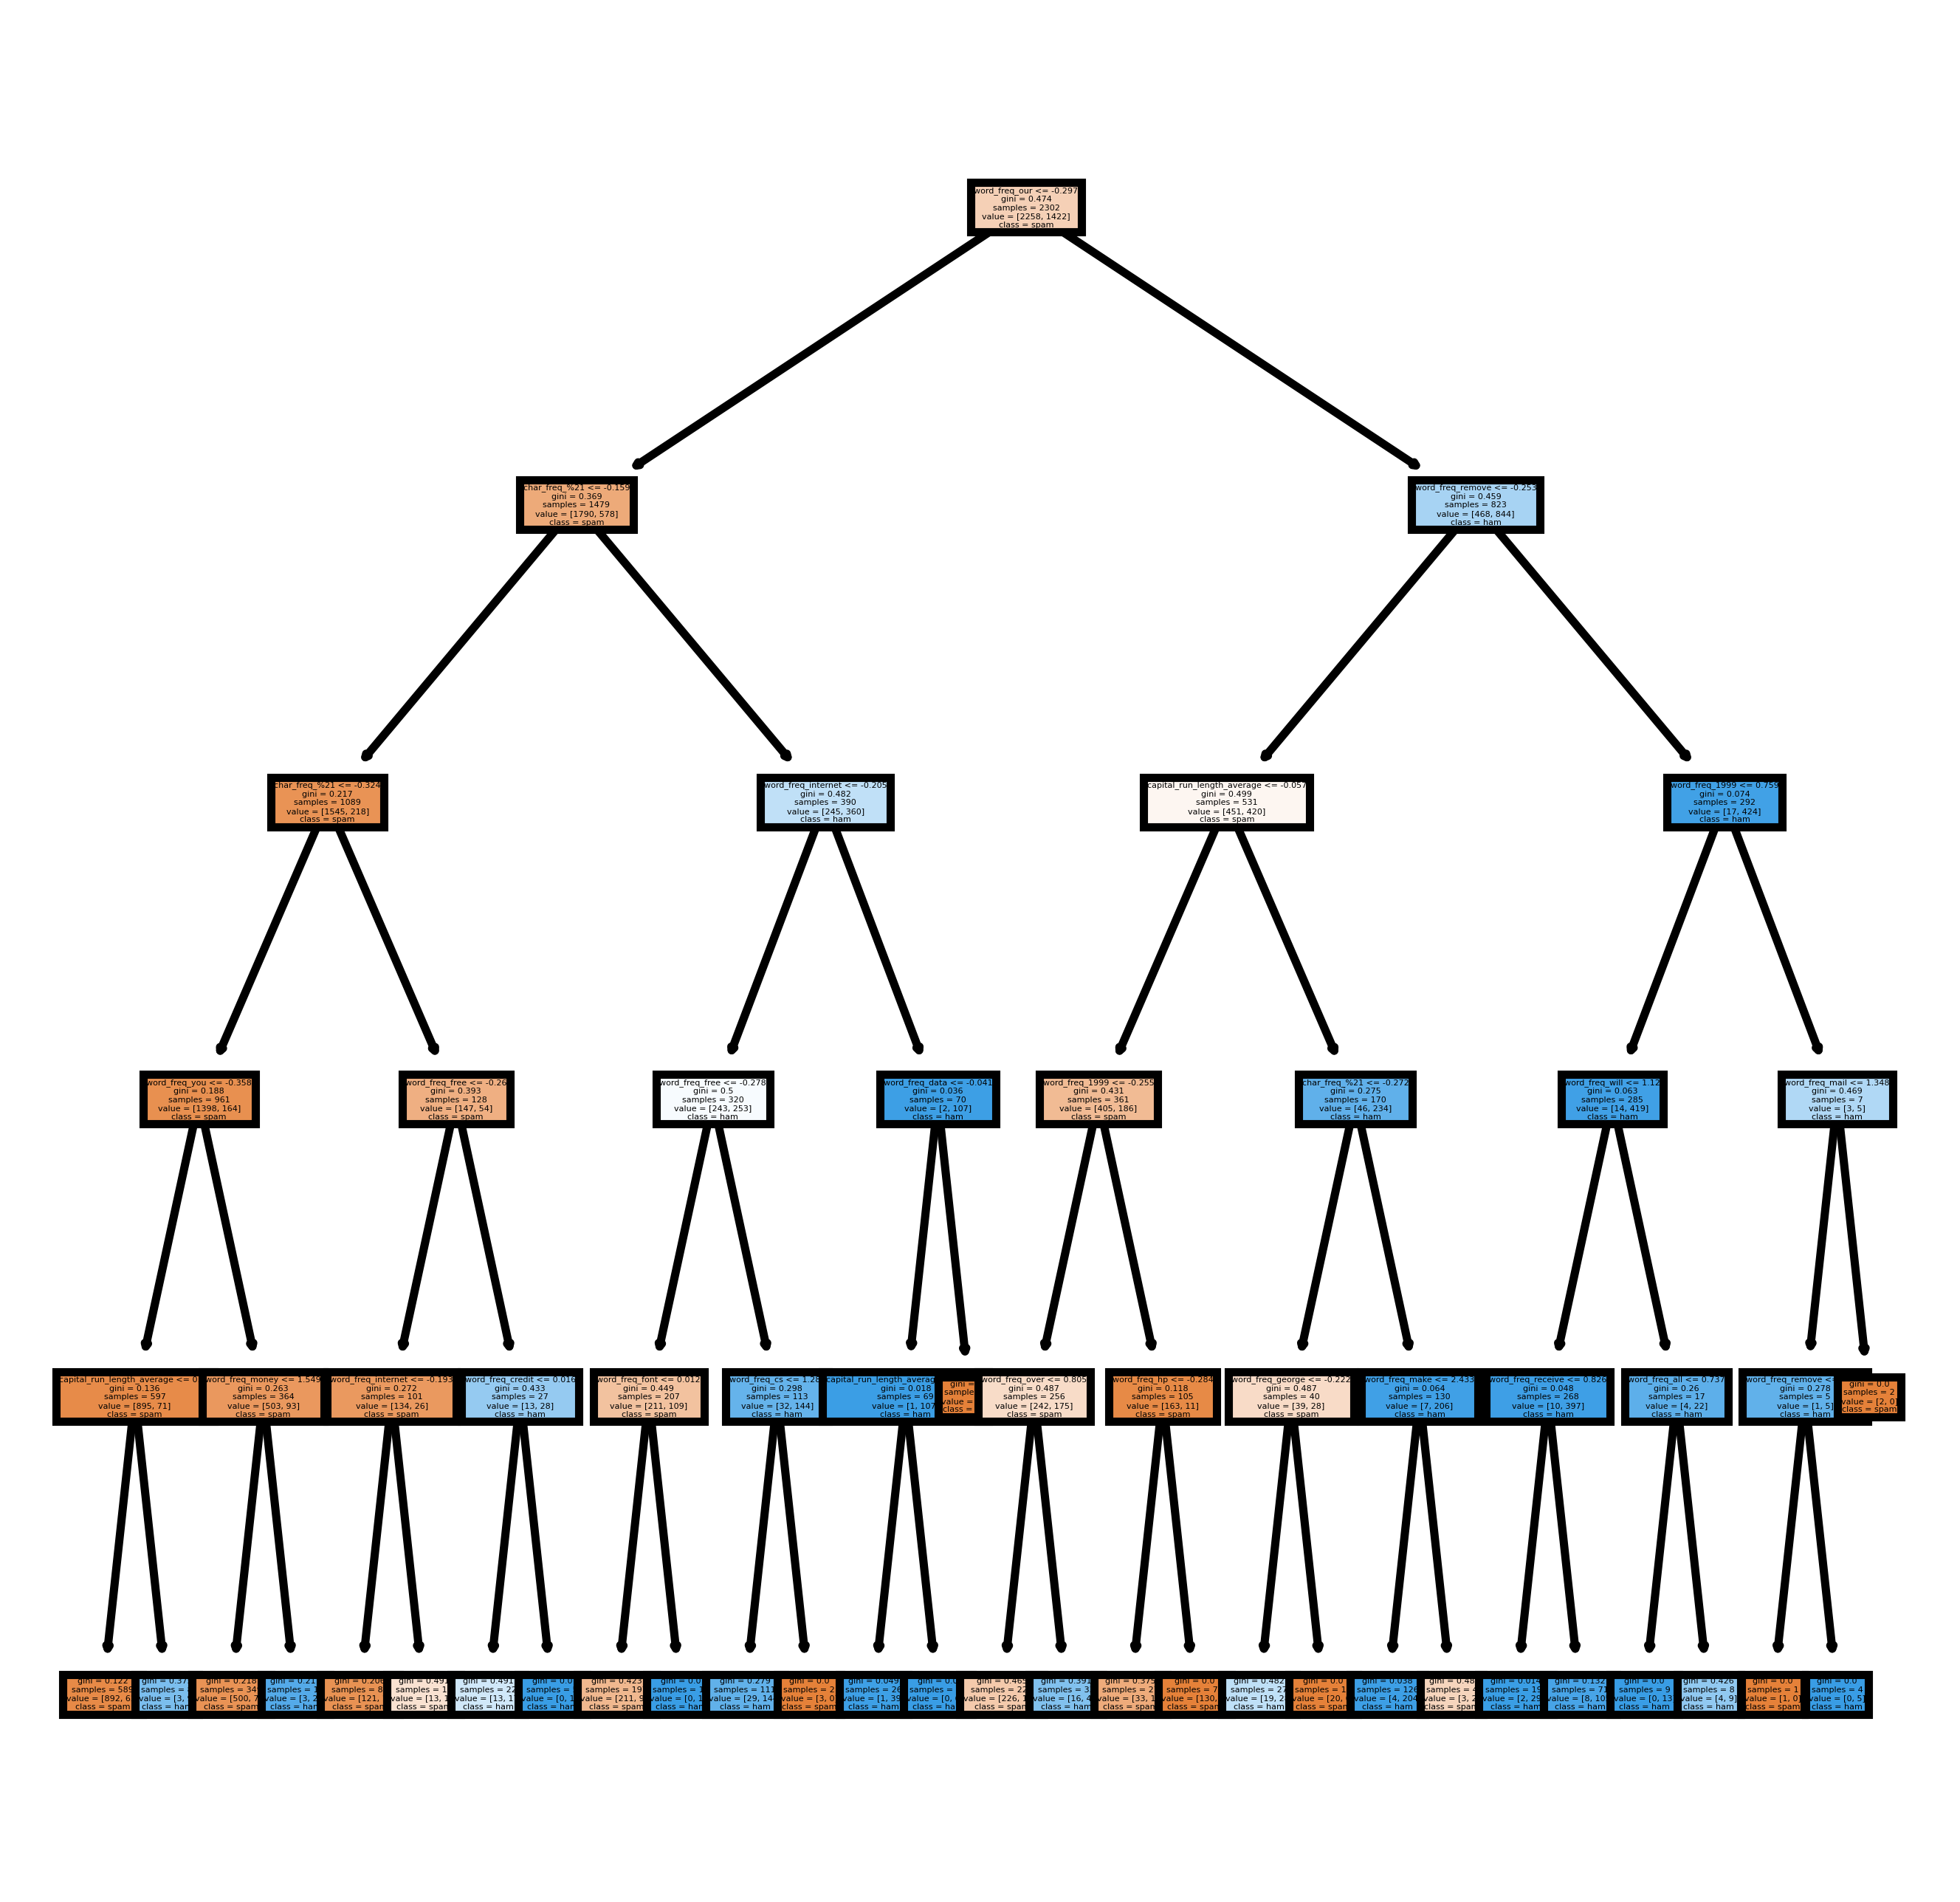

In [52]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
plot_tree(clf.estimators_[0], feature_names = X.columns, class_names=['spam', 'ham'], filled = True)
fig.savefig('forest_spambase.png')

<hr>

### * Ознаки притаманні моделям дерева та лісу дерев рішень

**Переваги**

•	<u>Зрозумілість при інтерпритації</u>: Дерева рішень відносно прості для розуміння та інтерпретації; 

•	<u>Працює з незбалансованими даними</u>: Цей метод не вимагає збалансованих даних для створення надійної моделі;

•	<u>Оптимальність вибору змінних</u>: Дерева рішень можуть визначити найбільш значущі змінні та зв'язок між двома або більше змінними;

•	<u>Обробка відсутніх значень</u>: Мають можливість обробляти відсутні значення в наборі даних, дивлячись на ймовірність спостереження;

•	<u>Непараметрична природа</u>: Не робиться жодних припущень щодо розподілу простору та структури класифікатора.

**Недолiки** 

•	<u>Перенавчання</u>: Це стосується створення надто складних дерев, які надто точно відповідають навчальним даним і погано працюють на невидимих даних;

•	<u>Чутливість до малих змін</u>: Навіть незначні зміни у вхідних даних можуть кардинально змінити структуру дерева рішень, впливаючи на його стабільність;

•	<u>Упереджене навчання</u>: Без належного налаштування параметрів дерева рішень мають тенденцію створювати упереджені дерева, якщо деякі класи домінують;

<u>**Застосування**<u>

Дерева рішень зазвичай використовуються в бізнесі для аналізу даних про клієнтів і прийняття маркетингових рішень, але вони також можуть застосовуватися в таких сферах, як медицина, фінанси та машинне навчання. Вони можуть працювати з різними типами даних - дискретними або неперервними значеннями, а неперервні значення можуть бути перетворені в категоріальні за допомогою використання порогових значень.